In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROC_DIR = Path("../data/processed")
LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

metrics = json.loads(Path("../reports/metrics.json").read_text())
best_model_name = "bert" if metrics["bert"]["macro_f1"] >= metrics["roberta"]["macro_f1"] else "roberta"
print("Auditing:", best_model_name)

test = pd.read_csv(PROC_DIR / "test_official_filtered.csv")
probs = np.load(PROC_DIR / f"{best_model_name}_test_probs.npy")
toxic_idx = LABEL_COLS.index("toxic")
test["pred_toxic"] = (probs[:, toxic_idx] >= 0.5).astype(int)


Auditing: bert


In [2]:
IDENTITY_TERMS = {
    "gender": ["woman", "women", "female", "man", "men", "male"],
    "sexual_orientation": ["gay", "lesbian", "homosexual", "queer", "transgender"],
    "religion": ["muslim", "christian", "jewish", "atheist"],
    "race_ethnicity": ["black", "white", "asian", "hispanic"],
    "disability": ["disabled", "mentally ill", "autistic"],
}

def contains_term(text, term):
    return re.search(rf"\b{re.escape(term)}\b", text, flags=re.IGNORECASE) is not None

for category, terms in IDENTITY_TERMS.items():
    for term in terms:
        col = f"mentions_{term.replace(' ', '_')}"
        test[col] = test["comment_text"].apply(lambda t: contains_term(t, term))


In [3]:
def false_positive_rate(df):
    non_toxic = df[df["toxic"] == 0]
    if len(non_toxic) == 0:
        return np.nan, 0
    return (non_toxic["pred_toxic"] == 1).mean(), len(non_toxic)

overall_fpr, overall_n = false_positive_rate(test)
print(f"Overall false positive rate: {overall_fpr:.3f} (n={overall_n})")

rows = []
for category, terms in IDENTITY_TERMS.items():
    for term in terms:
        col = f"mentions_{term.replace(' ', '_')}"
        subset = test[test[col]]
        fpr, n = false_positive_rate(subset)
        rows.append({"category": category, "term": term, "n_non_toxic": n,
                     "false_positive_rate": fpr, "gap_vs_overall": fpr - overall_fpr})

fpr_table = pd.DataFrame(rows).sort_values("gap_vs_overall", ascending=False)
fpr_table


Overall false positive rate: 0.143 (n=57888)


,category,term,n_non_toxic,false_positive_rate,gap_vs_overall
9,sexual_orientation,queer,21,0.619048,0.475633
6,sexual_orientation,gay,251,0.565737,0.422322
8,sexual_orientation,homosexual,73,0.506849,0.363434
7,sexual_orientation,lesbian,38,0.447368,0.303954
10,sexual_orientation,transgender,6,0.333333,0.189918
21,disability,autistic,16,0.312500,0.169085
0,gender,woman,203,0.310345,0.166930
3,gender,man,849,0.307420,0.164006
14,religion,atheist,39,0.256410,0.112995
15,race_ethnicity,black,585,0.244444,0.101030


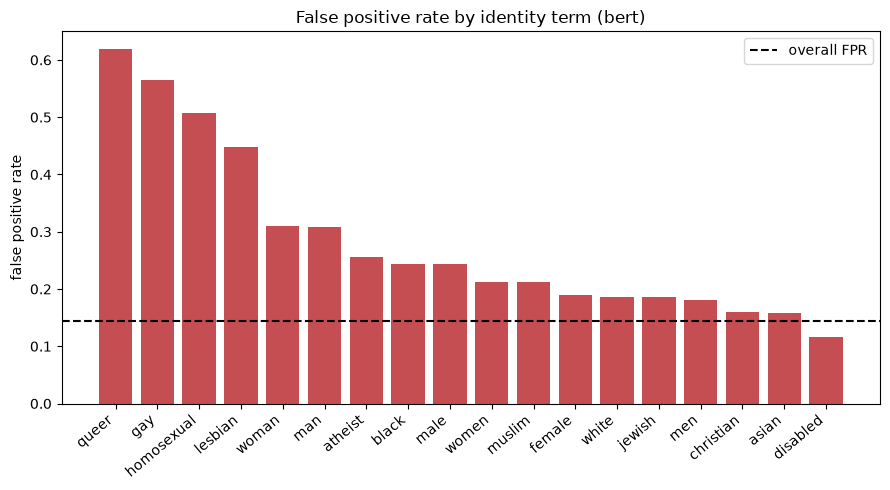

In [4]:
plot_df = fpr_table[fpr_table["n_non_toxic"] >= 20]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["term"], plot_df["false_positive_rate"], color="#C44E52")
ax.axhline(overall_fpr, color="black", linestyle="--", label="overall FPR")
ax.set_ylabel("false positive rate")
ax.set_title(f"False positive rate by identity term ({best_model_name})")
ax.legend()
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("../reports/bias_audit_fpr.png", dpi=150)
plt.show()


In [5]:
worst_terms = plot_df.sort_values("gap_vs_overall", ascending=False)["term"].head(2).tolist()

for term in worst_terms:
    col = f"mentions_{term.replace(' ', '_')}"
    examples = test[(test[col]) & (test["toxic"] == 0) & (test["pred_toxic"] == 1)]
    print(f"--- False positives mentioning '{term}' ---")
    for t in examples["comment_text"].head(2):
        print("-", t[:200].replace("\n", " "))
    print()


--- False positives mentioning 'queer' ---
- "       == ""hate speech"" ==    Can someone please explain this?    :The origination and use of cisgender can be compared to the reclamation of profane words and hate speech, such as nigger and queer
- Well I disagree. If a lesbian can be a homosexual, gay and a queer then they can certainly be a faggot and plenty of Conservatives refer to them as such. Do a Google search if you are in any doubt. Pe

--- False positives mentioning 'gay' ---
- == Gay? ==   He's gay too. It should be noted that he has a male partner.
- That's an interesting story. Unfortunately, this is Wikipedia, and no one cares about your specific situation. Also, where in the article does it say that emo kids are gay?

